In [ ]:
# LGBM & XGBM:

# Objective:
# The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset.

In [ ]:
# 1. Exploratory Data Analysis (EDA):
      # 1. Load the Titanic dataset using Python's pandas library.
      # 2. Check for missing values.
      # 3. Explore data distributions using histograms and box plots.
      # 4. Visualize relationships between features and survival using scatter plots and bar plots.

In [2]:
# Load the Dataset 
import pandas as pd 
df = pd.read_csv("diabetes (1).csv")

In [3]:
# Head of the dataset 
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Tail of the dataset 
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
# Shape of dataset 
df.shape

(768, 9)

In [6]:
# Columns of dataset 
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
# Statistica Summary 
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
# Check Missing Values 
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
# Check Duplicate 
df.duplicated().sum()

np.int64(0)

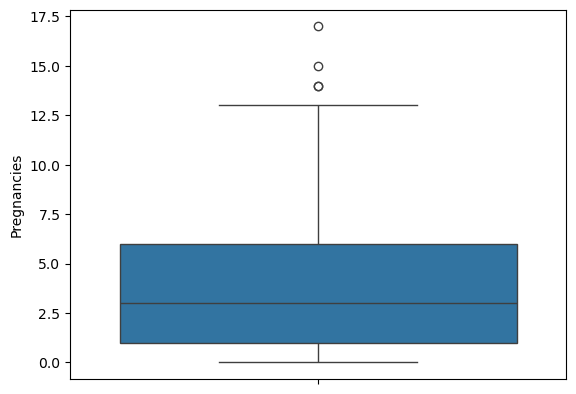

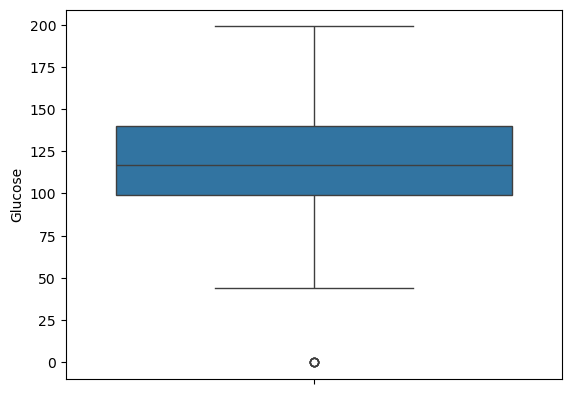

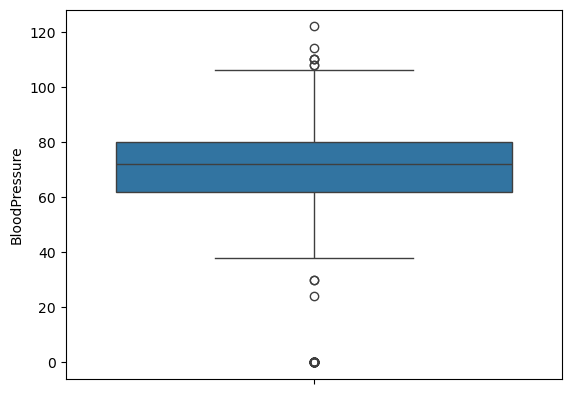

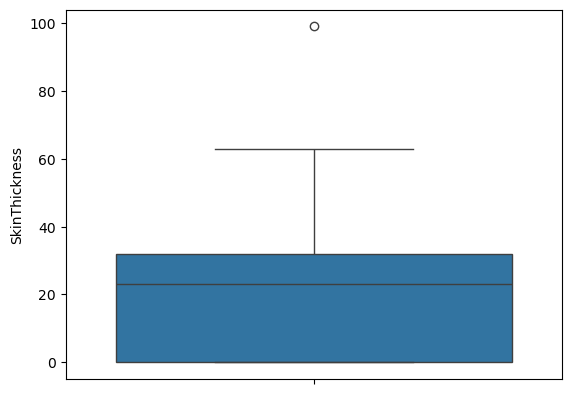

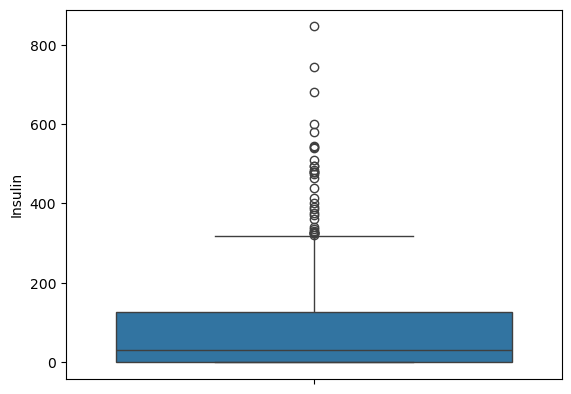

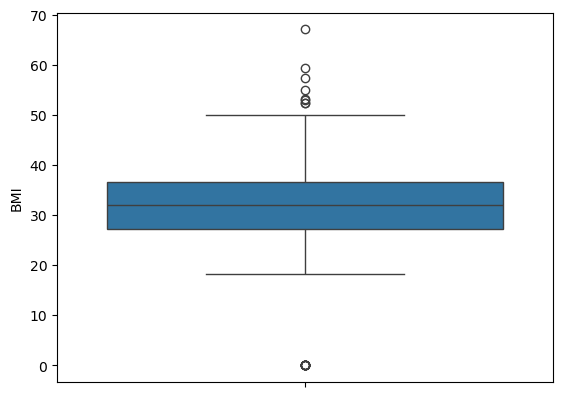

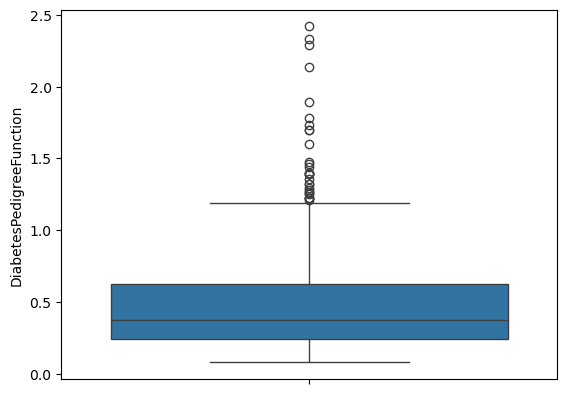

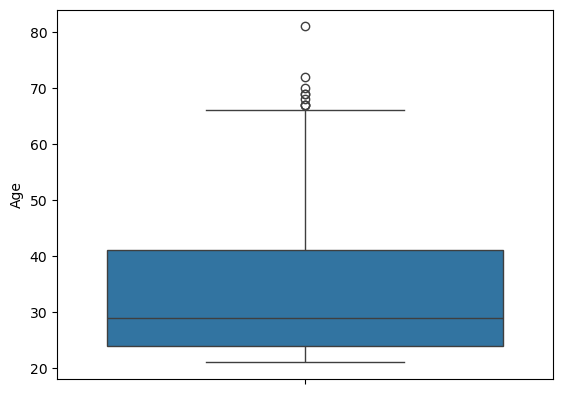

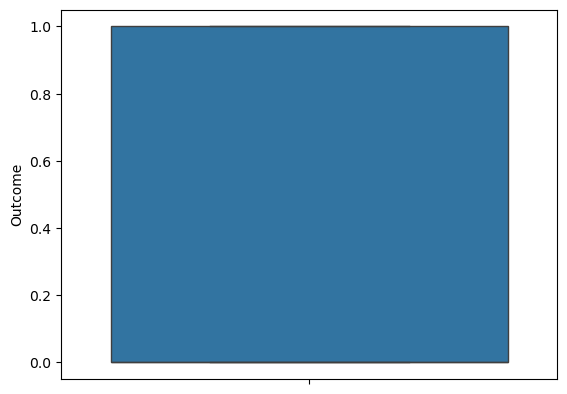

In [11]:
# Check Ouitlier 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

In [12]:
# Ouitlier Capping 

for i in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    IQR  = q3 - q1 

    lower_bound  = q1 - 1.5* IQR
    upper_bound = q3 + 1.5* IQR

    df[i] = df[i].clip(lower_bound, upper_bound)

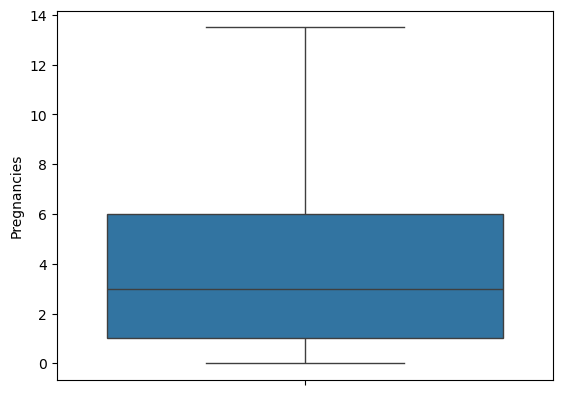

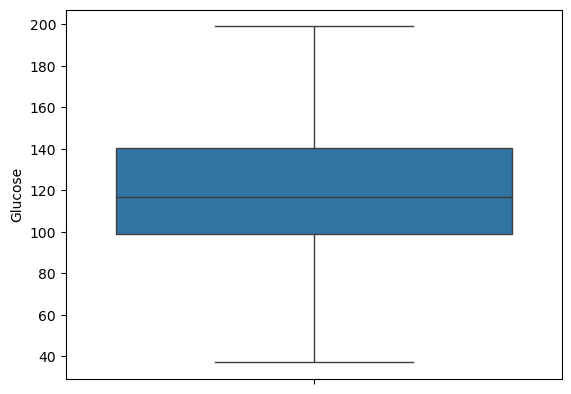

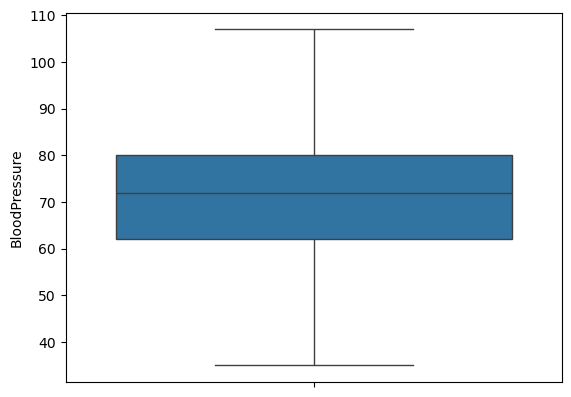

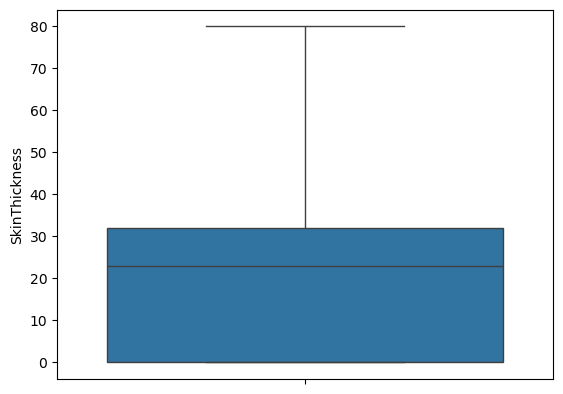

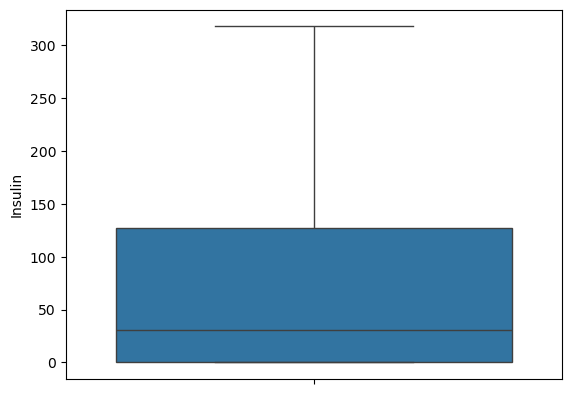

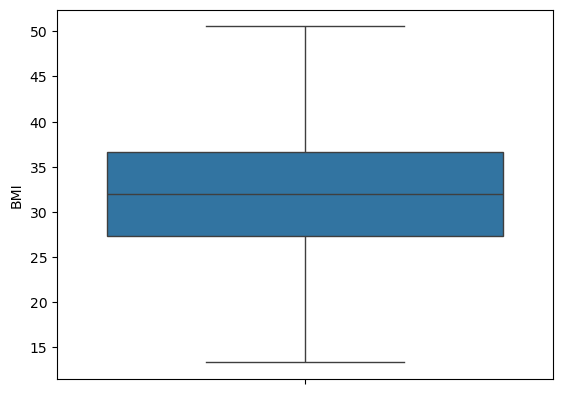

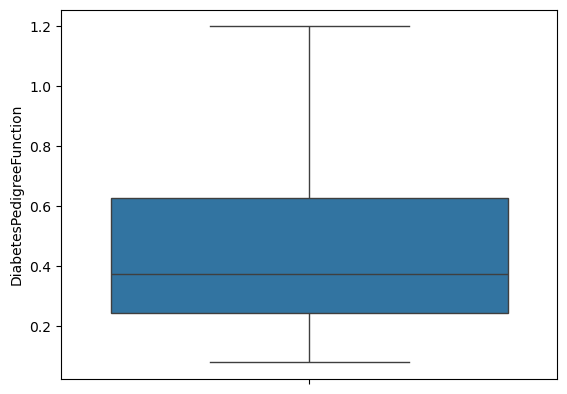

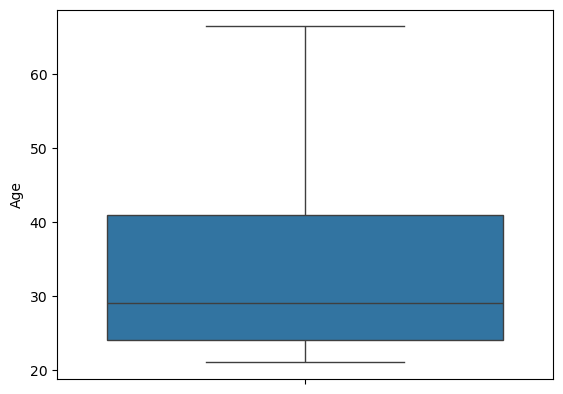

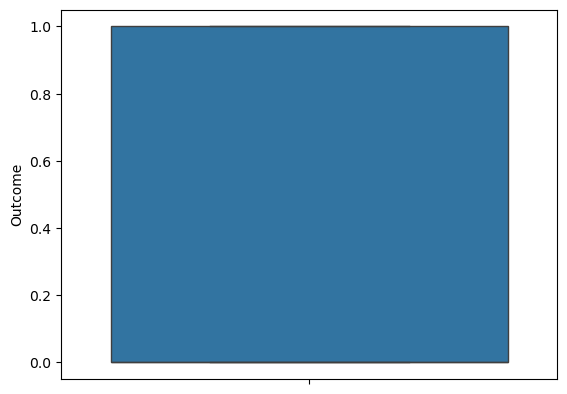

In [13]:
# Verify 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

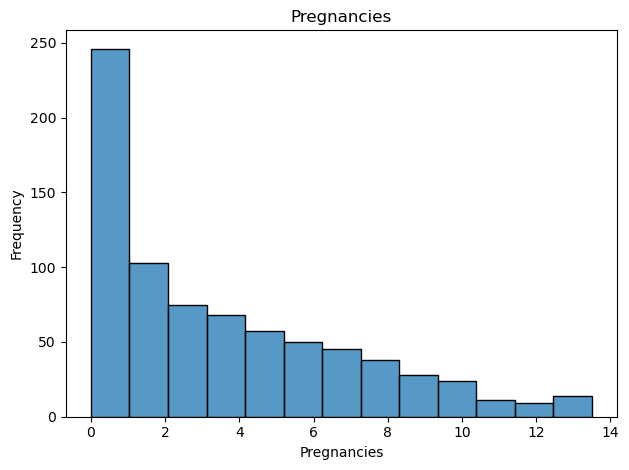

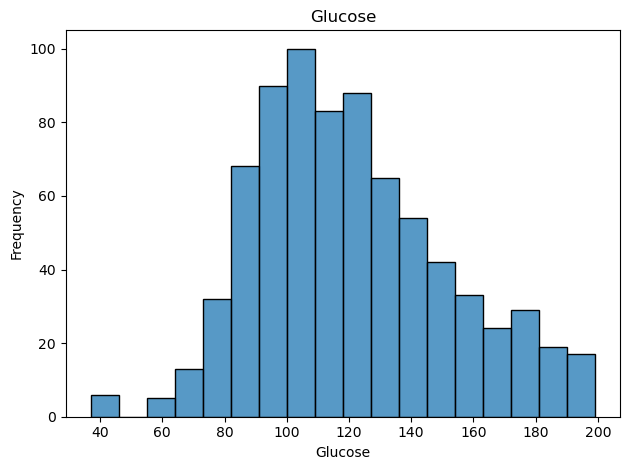

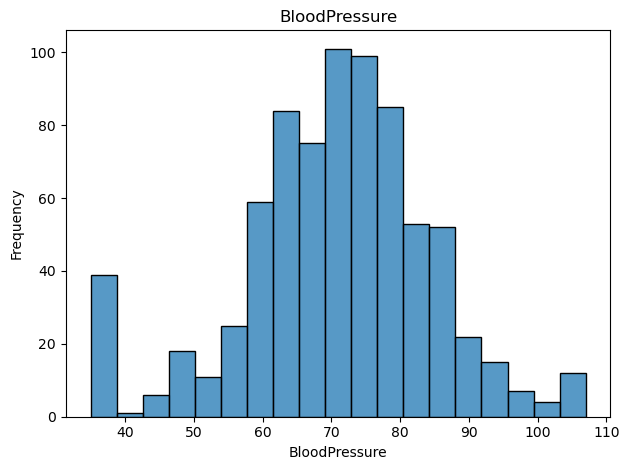

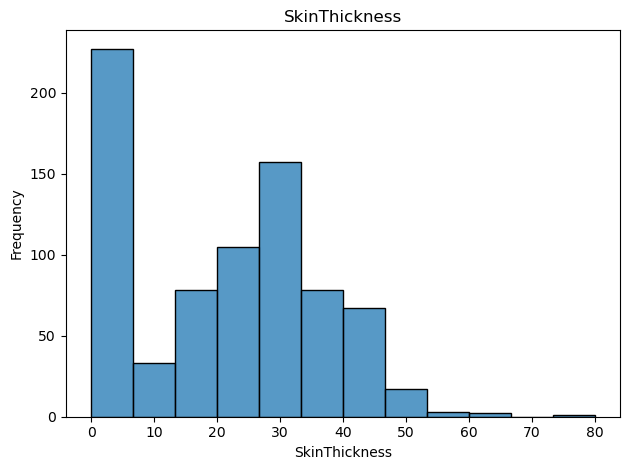

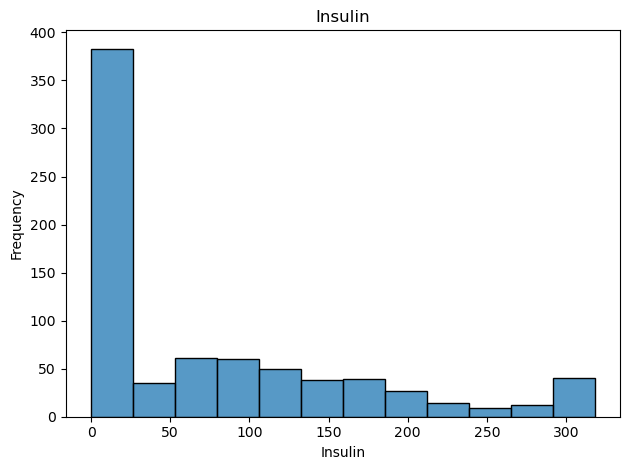

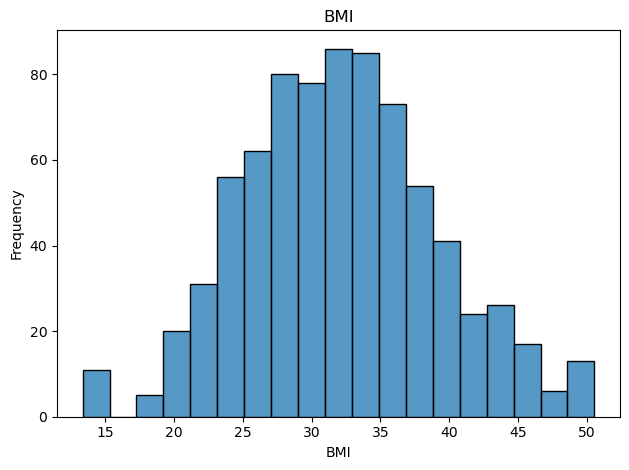

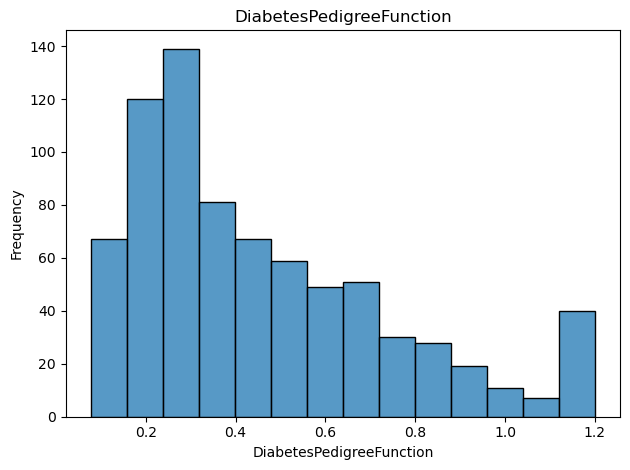

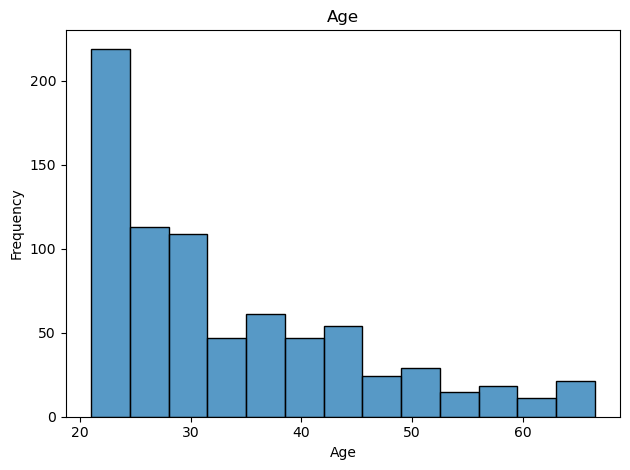

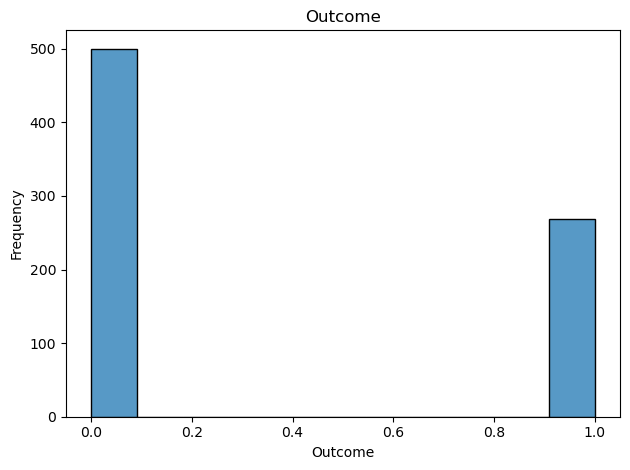

In [14]:
# Histogram plot 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in df.columns:
    sns.histplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.tight_layout()
    plt.show()

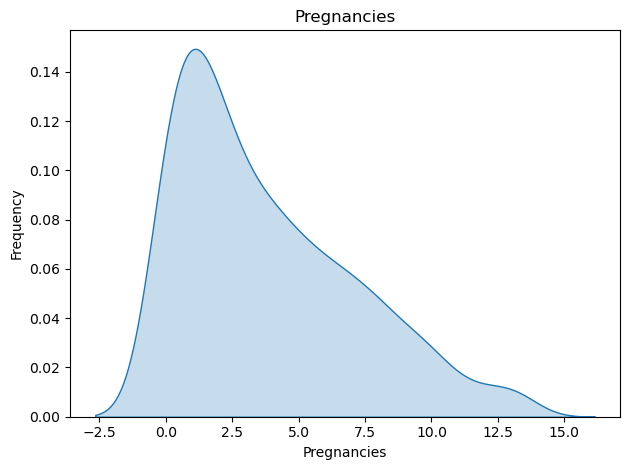

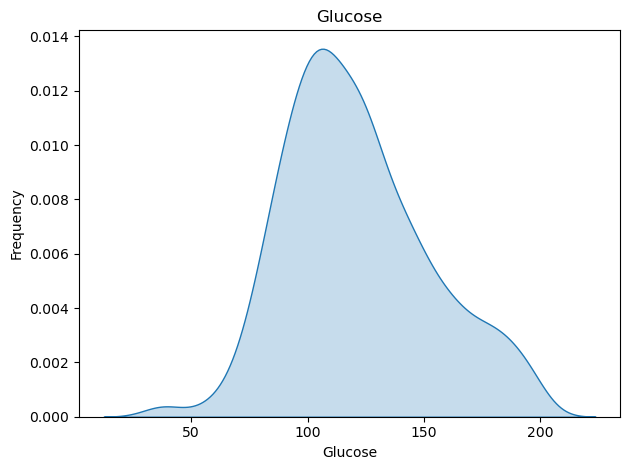

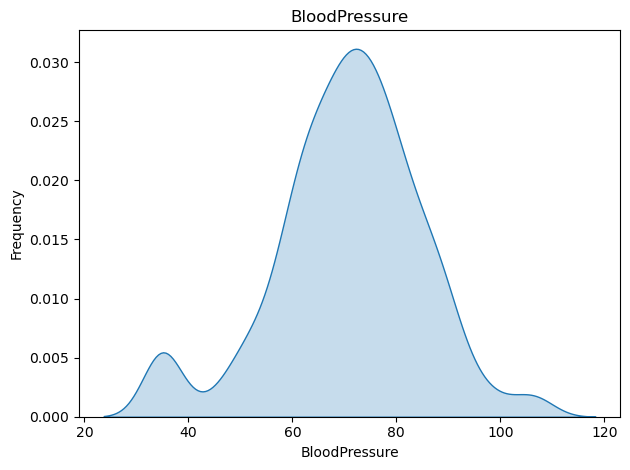

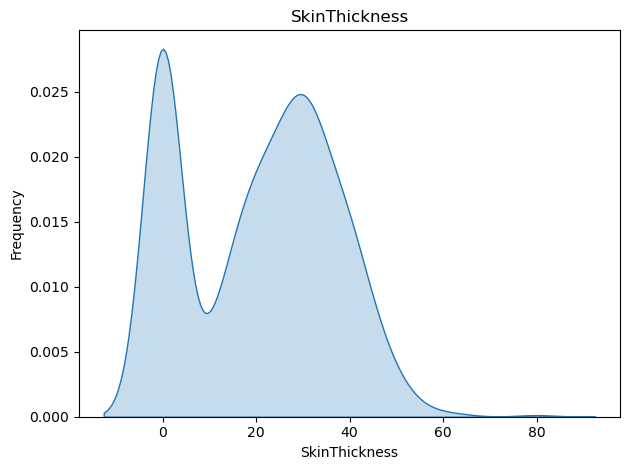

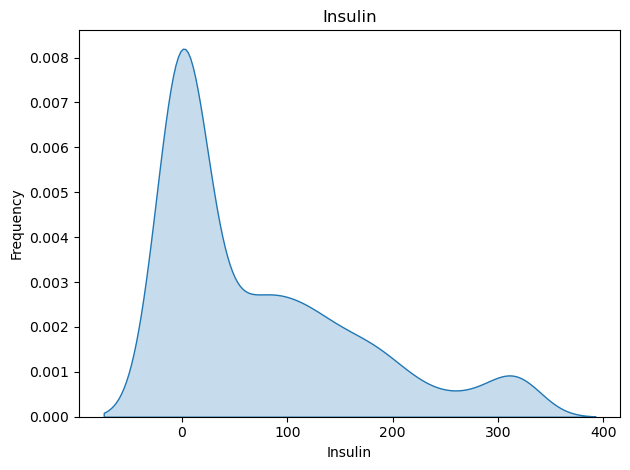

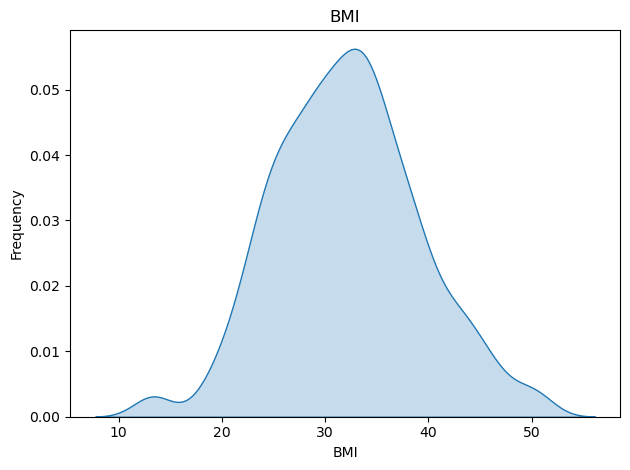

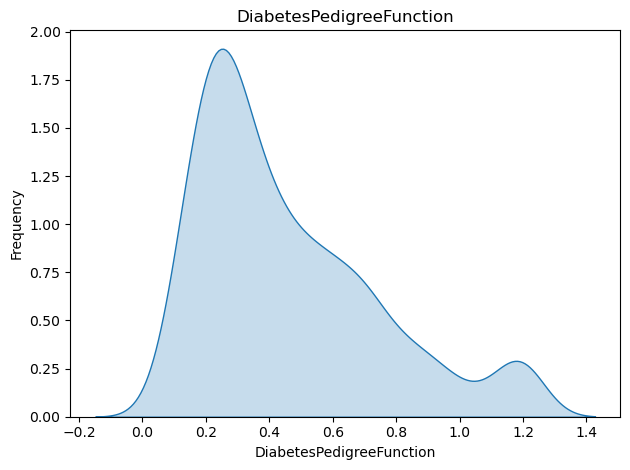

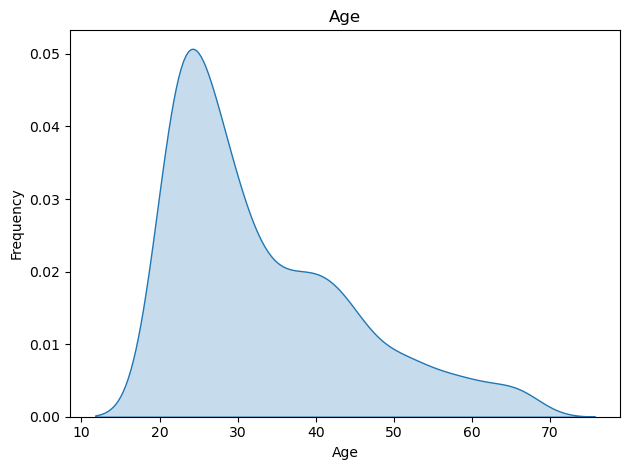

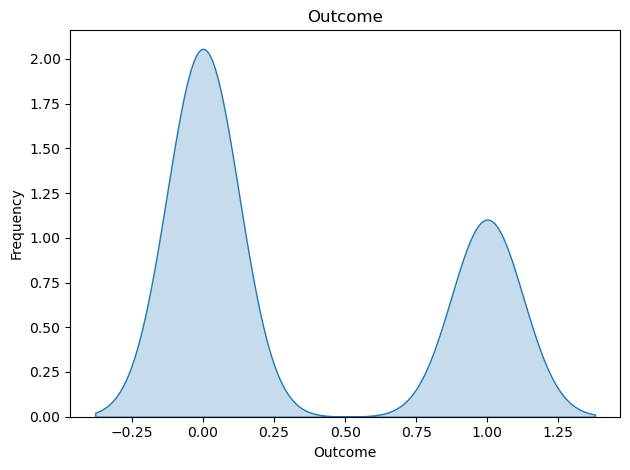

In [15]:
# KDE Plot 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in df.columns:
    sns.kdeplot(df[col], fill = True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.tight_layout()
    plt.show()

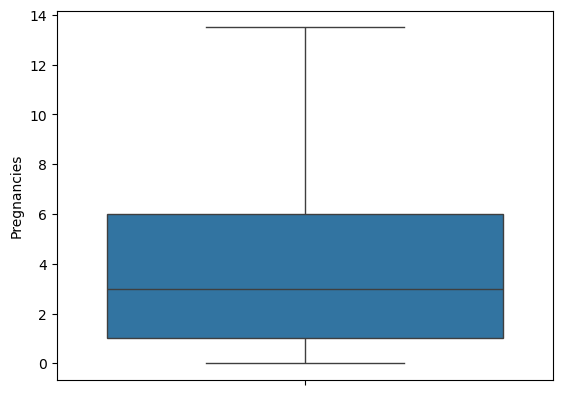

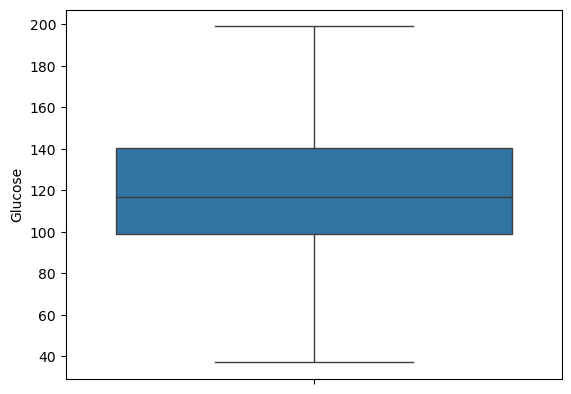

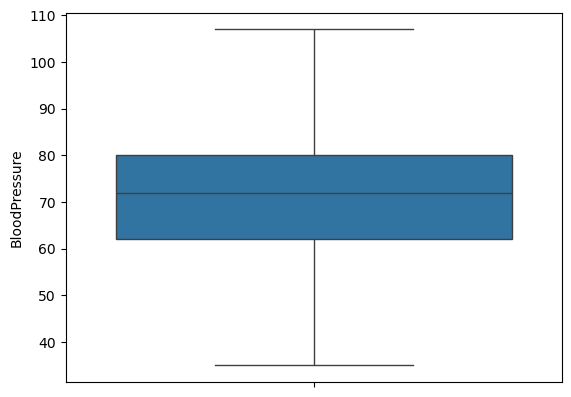

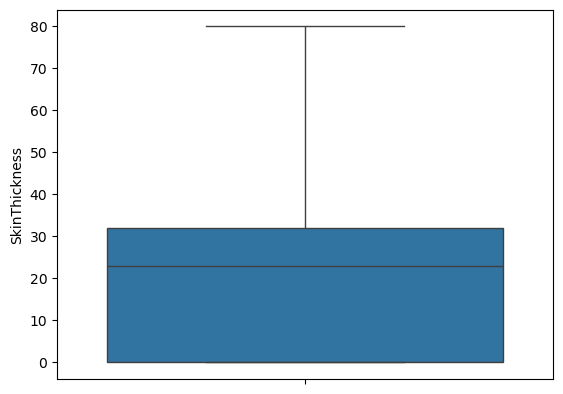

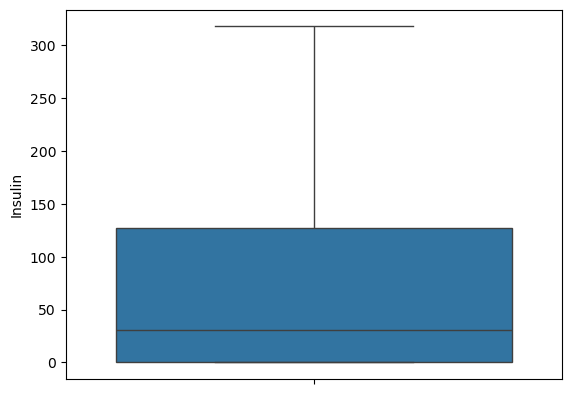

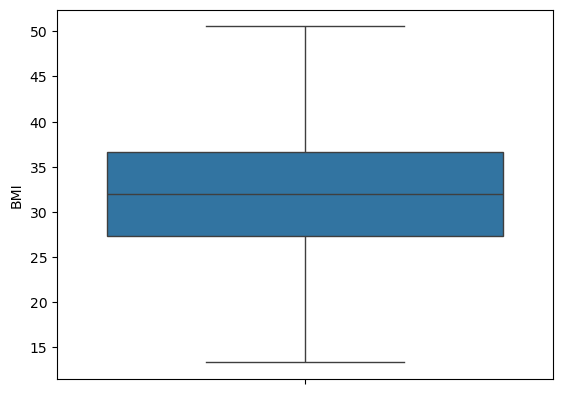

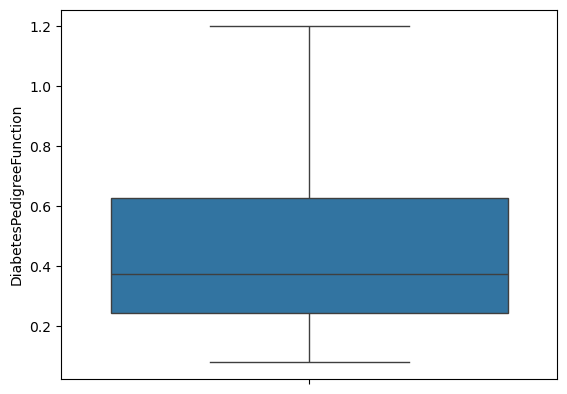

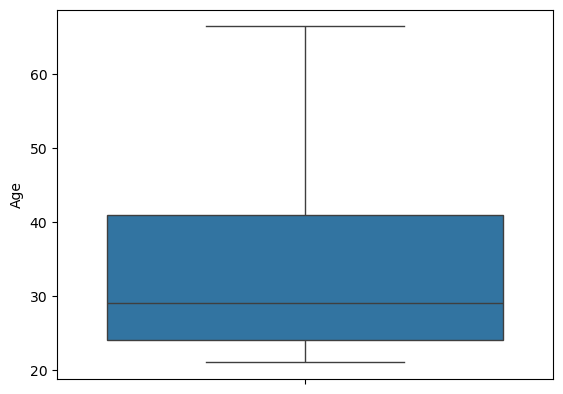

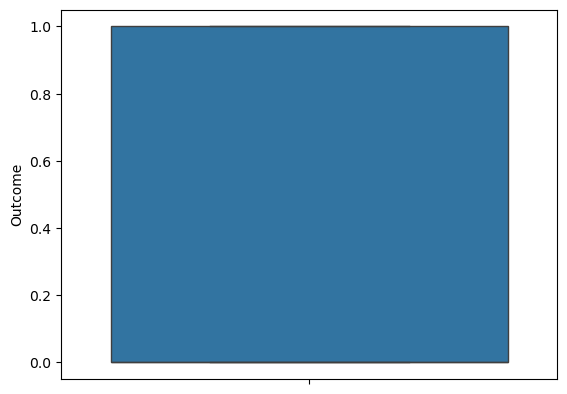

In [16]:
# Box Plot 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()

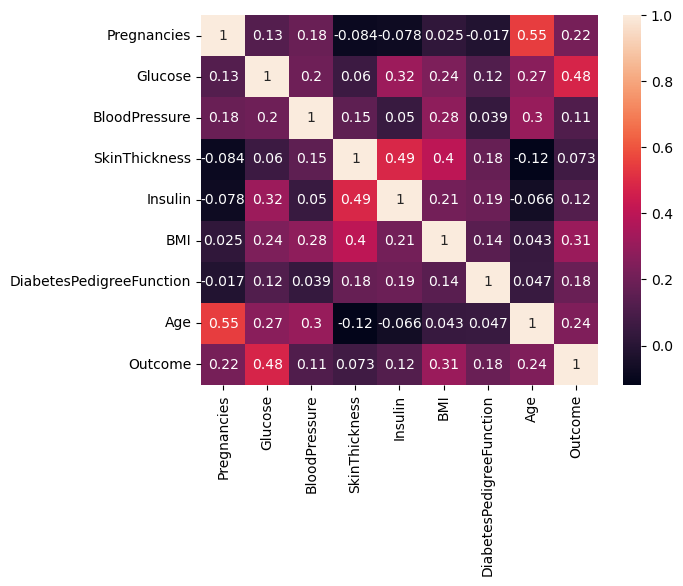

In [17]:
# Heatmap 

import matplotlib.pyplot as plt 
import seaborn as sns 

sns.heatmap(df.corr(numeric_only = True) ,annot= True)
plt.show()

In [ ]:
# 2. Data Preprocessing:
#        1. Impute missing values.
#        2. Encode categorical variables using one-hot encoding or label encoding.
#        3. If needed you can apply more preprocessing methods on the given dataset.

In [18]:
# Check Missing Values
missing = pd.DataFrame({
    "Missing" : df.isnull().sum(),
    "Precentage" : (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("Missing", ascending = False)

,Missing,Precentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


In [19]:
# Extract Categorical columns 
cat_cols = df.select_dtypes(include = 'object').columns
print("Categorical columsn :\n",cat_cols)

Categorical columsn :
 Index([], dtype='object')


In [ ]:
3. Building Predictive Models:
       1. Split the preprocessed dataset into training and testing sets.
       2. Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
       3. Build predictive models using LightGBM and XGBoost algorithms.
       4. Train the models on the training set and evaluate their performance on the testing set.
       5. Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

In [20]:
# Extract Features and Target 
x = df.drop(columns = 'Outcome')
y = df['Outcome']

In [21]:
# Split the dataset 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.2, 
                                                    random_state = 42,
                                                   stratify = y 
                                                   )

In [23]:
# Install xgboost if not already installed
!pip install xgboost

# GBoost Model
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Model Training
xgb.fit(x_train, y_train)

# Prediction
y_pred = xgb.predict(x_test)

# Probability
y_prob = xgb.predict_proba(x_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("XGBoost Classifier")
print("=" * 50)
print("Accuracy Score :", accuracy)
print("Precision Score:", precision)
print("Recall Score   :", recall)
print("F1 Score       :", f1)
print("ROC AUC        :", roc_auc)

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 5.0 MB/s eta 0:00:10
   -- ------------------------------------- 3.7/48.9 MB 9.3 MB/s eta 0:00:05
   ----- ---------------------------------- 6.3/48.9 MB 10.3 MB/s eta 0:00:05
   ------- -------------------------------- 8.9/48.9 MB 10.8 MB/s eta 0:00:04
   -------- ------------------------------- 10.7/48.9 MB 10.4 MB/s eta 0:00:04
   --------- ------------------------------ 11.8/48.9 MB 9.4 MB/s eta 0:00:04
   ---------- ----------------------------- 12.8/48.9 MB 8.7 MB/s eta 0:00:05
   ----------- ---------------------------- 14.7/48.9 MB 8.7 MB/s eta 0:00:04
   ------------- -------------------------- 16.8/48.9 MB 8.8 MB/s eta 0:00:04
   -------------- ------------------------- 18.4/48.9 MB 8.9 MB/s eta 0:00:04
   --------------- ------------------------ 19.4/48.9 MB 8.3 MB/s eta 0:00:04
   ----------------- ---------------------- 21.2/48.9 MB 8.3 MB/s eta 0:0

In [24]:
# Install the model 
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   -------------------------------------- - 1.3/1.4 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.2 MB/s  0:00:00


In [25]:
# LightGBM Model
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)

# Model Training
lgbm.fit(x_train, y_train)

# Prediction
y_pred = lgbm.predict(x_test)

# Probability
y_prob = lgbm.predict_proba(x_test)[:, 1]

# Metrics
lgbm_accuracy = accuracy_score(y_test, y_pred)
lgbm_precision = precision_score(y_test, y_pred)
lgbm_recall = recall_score(y_test, y_pred)
lgbm_f1 = f1_score(y_test, y_pred)
lgbm_roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("LightGBM Classifier")
print("=" * 50)

print("Accuracy Score :", lgbm_accuracy)
print("Precision Score:", lgbm_precision)
print("Recall Score   :", lgbm_recall)
print("F1 Score       :", lgbm_f1)
print("ROC AUC        :", lgbm_roc_auc)

LightGBM Classifier
Accuracy Score : 0.7662337662337663
Precision Score: 0.6666666666666666
Recall Score   : 0.6666666666666666
F1 Score       : 0.6666666666666666
ROC AUC        : 0.8188888888888889


In [26]:
# Using Cross Validation and Diffrent Hyperparameter
# XGBoost — Hyperparameter Tuning
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(x_train, y_train)

print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_xgb.best_score_)
# Evaluate the best model on the test set
best_gb_model = grid_xgb.best_estimator_
y_pred_test_best = best_gb_model.predict(x_test)
test_accuracy_best = accuracy_score(y_test, y_pred_test_best)
print("Test accuracy of best model:", test_accuracy_best)


best_xgb = grid_xgb.best_estimator_

y_pred = best_xgb.predict(x_test)
y_prob = best_xgb.predict_proba(x_test)[:, 1]

print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall   :", recall_score(y_test, y_pred))
print("Test F1 Score :", f1_score(y_test, y_pred))
print("Test ROC AUC  :", roc_auc_score(y_test, y_prob))

Best Parameters:
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

Best Cross-Validation F1 Score:
0.6354042312553132
Test accuracy of best model: 0.7597402597402597
Test Precision: 0.6888888888888889
Test Recall   : 0.5740740740740741
Test F1 Score : 0.6262626262626263
Test ROC AUC  : 0.8148148148148148


In [ ]:
4. Comparative Analysis:
   a. Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

In [27]:
# Performance compare of GBM & LGBM
compare = pd.DataFrame({
    "Columns" : ['GBM', "LGBM"],
    "Accuracy Score" : [accuracy, lgbm_accuracy],
    "Precision Score" : [precision, lgbm_precision],
    "F1 Score" : [f1, lgbm_f1],
    "ROC AUC" : [roc_auc,lgbm_roc_auc]
})
compare.sort_values("Accuracy Score", ascending = False)

,Columns,Accuracy Score,Precision Score,F1 Score,ROC AUC
1,LGBM,0.766234,0.666667,0.666667,0.818889
0,GBM,0.753247,0.666667,0.627451,0.829815


In [ ]:
# 2. Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.
# LGBM performed slightly better overall than GBM, achieving an accuracy of 76.62% and an F1 score of 66.67%. Both models achieved the same precision of 66.67%. However, GBM achieved a higher ROC-AUC of 82.98% compared with 81.89% for LGBM, indicating slightly better class discrimination. Overall, LGBM can be considered the better model because it provides higher accuracy and F1 score, while maintaining the same precision.